# 02 - Feature engineering

**Problem this notebook solves.** The plan calls for acute (7d) vs chronic (28d) load
and their ratio - but the day-approach table is already a 7-day sliding window, so a
single row cannot see 28 days back. The fix: the windows *overlap* (a given calendar
day appears in up to 7 consecutive rows), so the per-athlete **daily series can be
reconstructed exactly** from the slots, then any backward-looking window computed from
it. The reconstruction is validated against the source rows before anything is built
on it.

Ground rules carried from 01_eda and `docs/assumptions_limitations.md`:

- Slot ordering (proven in 01): `.6` = most recent day (= the row's `Date`, injury day
  on positive rows); unsuffixed = oldest (t-6).
- A zero-km logged day is real rest. Truly unlogged days are the ones covered by *no*
  row's window - they stay NaN, and windows are coverage-gated rather than
  zero-filled (zero-filling would fabricate rest).
- All windows look backward only, computed per athlete.
- Both prediction framings are computed and labeled - **same-day** (window ends at t,
  the paper's framing) and **prospective** (window ends at t-1, what a triage tool
  would actually have). Which one 03 leads with is Austin's call; producing both makes
  the comparison itself cheap.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path('../data/raw')
OUT = Path('../data/processed')
OUT.mkdir(exist_ok=True)

BASE = ['nr. sessions', 'total km', 'km Z3-4', 'km Z5-T1-T2', 'km sprinting',
        'strength training', 'hours alternative', 'perceived exertion',
        'perceived trainingSuccess', 'perceived recovery']

day = pd.read_csv(RAW / 'day_approach_maskedID_timeseries.csv.gz')
print(day.shape)

(42766, 73)


## 1. Reconstruct the per-athlete daily series

Row at `Date` t carries slots for calendar days t-6 .. t (slot k -> day t-(6-k)).
Melt all 7 slots of all rows into a long (athlete, day, metric) table, then:

1. **Consistency check:** where the same (athlete, day) is covered by several
   overlapping rows, all copies must agree. 01_eda proved this for step-1 pairs; this
   check covers every overlap (including across small gaps). If it fails, the
   reconstruction idea dies here.
2. Deduplicate to one record per (athlete, day).

In [2]:
blocks = []
for k in range(7):                       # slot k covers day = Date - (6-k)
    cols = BASE if k == 0 else [f'{b}.{k}' for b in BASE]
    blk = day[cols].copy()
    blk.columns = BASE
    blk['Athlete ID'] = day['Athlete ID'].values
    blk['day'] = day['Date'].values - (6 - k)
    blocks.append(blk)
long = pd.concat(blocks, ignore_index=True)
print('slot records:', len(long))

g = long.groupby(['Athlete ID', 'day'])[BASE]
spread = (g.max() - g.min()).abs().to_numpy().max()
print('max disagreement across overlapping copies of the same (athlete, day):', spread)
assert spread < 1e-9, 'overlapping windows disagree - reconstruction is NOT valid'

daily = g.first().reset_index()
print('reconstructed daily records:', len(daily), 'athletes:', daily['Athlete ID'].nunique())

slot records: 299362
max disagreement across overlapping copies of the same (athlete, day): 0.0
reconstructed daily records: 49162 athletes: 74


In [3]:
# 'day' can go negative: the first labeled rows' windows reach back before global
# Date 0. First guess was that these are zero padding - they are NOT: some athletes
# have real km logged there (e.g. athlete 0, day -1: 16.4 km). They are genuine
# training history that precedes the first prediction row, so they stay in the daily
# series as observed days. Labels only ever attach at row Dates >= 0.
neg = daily[daily['day'] < 0]
print('records at day < 0:', len(neg),
      '| carrying nonzero data:', int((neg[BASE].to_numpy() != 0).any(axis=1).sum()))
print('example - athlete 0 around day 0:')
print(daily[(daily['Athlete ID'] == 0) & daily['day'].between(-3, 2)]
      [['day', 'nr. sessions', 'total km']].to_string(index=False))

records at day < 0: 206 | carrying nonzero data: 206
example - athlete 0 around day 0:
 day  nr. sessions  total km
  -3           0.0       0.0
  -2           1.0       0.0
  -1           1.0      16.4
   0           1.0       0.0
   1           1.0       5.2
   2           0.0       0.0


In [4]:
# Coverage: how much of each athlete's calendar span is actually observed?
span = daily.groupby('Athlete ID')['day'].agg(['min', 'max'])
span['span_days'] = span['max'] - span['min'] + 1
span['observed'] = daily.groupby('Athlete ID').size()
span['coverage'] = span['observed'] / span['span_days']
print(span['coverage'].describe().round(3))
print('\nathletes with <70% of their span observed:', int((span.coverage < .7).sum()))

count    74.000
mean      0.689
std       0.175
min       0.351
25%       0.577
50%       0.669
75%       0.782
max       1.000
Name: coverage, dtype: float64

athletes with <70% of their span observed: 43


**Reconstruction verdict.** Zero disagreement across all overlapping copies, so the
daily series is exact, not an estimate. Coverage varies by athlete; the unobserved
days stay NaN and are handled by per-window coverage gating below, never zero-filled.

## 2. Feature definitions

Adopted domain guidance, not invention: the acute:chronic workload ratio (ACWR)
follows Hulin et al. (2016, BJSM) / Gabbett (2016) - acute = 7-day load, chronic =
28-day load scaled to weekly units, both from simple rolling sums. Known critiques
exist (Impellizzeri et al. 2020 question ACWR's causal reading; EWMA variants -
Williams et al. 2017 - weight recent days more). This repo treats ACWR as a candidate
*feature*, not a validated injury law; the model decides whether it earns its keep.

| feature | window | definition |
|---|---|---|
| `km_7d`, `sessions_7d` | 7d | rolling sums of total km / session count |
| `km_28d` | 28d | rolling sum of total km |
| `acwr` | 7d vs 28d | `km_7d / (km_28d / 4)` - coupled form (acute week included in chronic); NaN when chronic is 0 |
| `pct_km_mod_7d` | 7d | Z3-4 km share of total km (NaN when no km) |
| `pct_km_hi_7d` | 7d | (Z5-T1-T2 + sprint) km share of total km |
| `rest_days_7d`, `rest_days_14d` | 7/14d | logged days with 0 sessions |
| `strength_7d`, `alt_hours_7d` | 7d | strength sessions / alternative-training hours |
| `exertion_avg_7d`, `recovery_avg_7d`, `success_avg_7d` | 7d | means of the subjective 0-1 scores over logged days |
| `wow_km_change` | 14d | `km(last 7) / km(prior 7) - 1` (NaN when prior week is 0) |

**DECISION (defaults chosen, Austin to confirm or change one constant):**
- *Coupled* ACWR (the common form; uncoupled subtracts the acute week from chronic).
- Coverage gates: a 7d window needs >=5 logged days, 14d >=10, 28d >=20, else the
  feature is NaN for that day. Rationale: windows straddling big gaps span months of
  real time (01_eda finding); gating refuses to pretend they are a week. The gate
  thresholds are judgment calls - sensitivity to them is cheap to test in 03.

In [5]:
GATE = {7: 5, 14: 10, 28: 20}   # min logged days required per window length

def roll(s, w, stat='sum'):
    r = s.rolling(w, min_periods=1)
    return r.sum() if stat == 'sum' else r.mean()

def build_features(a):
    """a: one athlete's daily records, reindexed to a full calendar range.
    All windows end at the current day t (same-day framing); the prospective
    variant is derived afterwards by shifting one day."""
    idx = np.arange(a['day'].min(), a['day'].max() + 1)
    a = a.set_index('day').reindex(idx)
    logged = a['nr. sessions'].notna()

    f = pd.DataFrame(index=idx)
    n7, n14, n28 = [roll(logged.astype(float), w) for w in (7, 14, 28)]

    km7  = roll(a['total km'].fillna(0), 7)
    km28 = roll(a['total km'].fillna(0), 28)
    f['km_7d']  = km7.where(n7 >= GATE[7])
    f['km_28d'] = km28.where(n28 >= GATE[28])
    f['sessions_7d'] = roll(a['nr. sessions'].fillna(0), 7).where(n7 >= GATE[7])

    chronic_weekly = km28 / 4
    f['acwr'] = (km7 / chronic_weekly.replace(0, np.nan)).where(
        (n7 >= GATE[7]) & (n28 >= GATE[28]))

    mod7 = roll(a['km Z3-4'].fillna(0), 7)
    hi7  = roll((a['km Z5-T1-T2'].fillna(0) + a['km sprinting'].fillna(0)), 7)
    f['pct_km_mod_7d'] = (mod7 / km7.replace(0, np.nan)).where(n7 >= GATE[7])
    f['pct_km_hi_7d']  = (hi7  / km7.replace(0, np.nan)).where(n7 >= GATE[7])

    rest = (logged & (a['nr. sessions'] == 0)).astype(float)
    f['rest_days_7d']  = roll(rest, 7).where(n7 >= GATE[7])
    f['rest_days_14d'] = roll(rest, 14).where(n14 >= GATE[14])

    f['strength_7d']  = roll(a['strength training'].fillna(0), 7).where(n7 >= GATE[7])
    f['alt_hours_7d'] = roll(a['hours alternative'].fillna(0), 7).where(n7 >= GATE[7])

    for src, name in [('perceived exertion', 'exertion_avg_7d'),
                      ('perceived recovery', 'recovery_avg_7d'),
                      ('perceived trainingSuccess', 'success_avg_7d')]:
        f[name] = roll(a[src], 7, 'mean').where(n7 >= GATE[7])

    prior7 = km7.shift(7)
    f['wow_km_change'] = (km7 / prior7.replace(0, np.nan) - 1).where(n14 >= GATE[14])
    return f

feats = {aid: build_features(a) for aid, a in daily.groupby('Athlete ID')}
print('built features for', len(feats), 'athletes')

built features for 74 athletes


## 3. Attach labels, produce both framings

Prediction points are the day-table rows (they carry the injury label at `Date` t).

- **same-day**: features from windows ending at t (includes the injury day's own load)
- **prospective**: the same features shifted to end at t-1 (nothing from day t)

In [6]:
rows = []
for aid, a in day.groupby('Athlete ID'):
    f = feats[aid]
    lab = a[['Date', 'injury']].set_index('Date')
    same = f.reindex(lab.index).add_suffix('__same')
    pros = f.shift(1).reindex(lab.index).add_suffix('__pros')
    out = pd.concat([lab, same, pros], axis=1)
    out.insert(0, 'Athlete ID', aid)
    rows.append(out.reset_index().rename(columns={'index': 'Date'}))
X = pd.concat(rows, ignore_index=True)
print(X.shape, '| positives:', int(X.injury.sum()))
X.head(3)

(42766, 31) | positives: 583


,Date,Athlete ID,injury,km_7d__same,km_28d__same,sessions_7d__same,acwr__same,pct_km_mod_7d__same,pct_km_hi_7d__same,rest_days_7d__same,...,pct_km_mod_7d__pros,pct_km_hi_7d__pros,rest_days_7d__pros,rest_days_14d__pros,strength_7d__pros,alt_hours_7d__pros,exertion_avg_7d__pros,recovery_avg_7d__pros,success_avg_7d__pros,wow_km_change__pros
0,0,0,0,22.2,NaN,5.0,NaN,0.450450,0.081081,2.0,...,0.450450,0.081081,2.0,NaN,2.0,1.08,0.063333,0.113333,-0.003333,NaN
1,1,0,0,21.6,NaN,5.0,NaN,0.462963,0.078704,2.0,...,0.450450,0.081081,2.0,NaN,2.0,2.08,0.068571,0.118571,-0.002857,NaN
2,2,0,0,21.6,NaN,5.0,NaN,0.462963,0.078704,2.0,...,0.462963,0.078704,2.0,NaN,2.0,2.08,0.067143,0.117143,-0.002857,NaN


In [7]:
# Sanity anchor: same-day km_7d must equal the source row's own 7-slot sum wherever
# the window is fully inside the athlete's observed span (no gating involved: every
# day in a row's window is covered by construction).
slot_sum = sum(day[c if k == 0 else f'total km.{k}'] for k, c in
               [(k, 'total km') for k in range(7)])
chk = pd.DataFrame({'aid': day['Athlete ID'], 'Date': day['Date'], 'slot_sum': slot_sum})
merged = chk.merge(X[['Athlete ID', 'Date', 'km_7d__same']],
                   left_on=['aid', 'Date'], right_on=['Athlete ID', 'Date'])
ok = merged['km_7d__same'].notna()
err = (merged.loc[ok, 'km_7d__same'] - merged.loc[ok, 'slot_sum']).abs().max()
print(f'rows compared: {ok.sum():,} | max |reconstructed - source| = {err:.2e}')
assert err < 1e-6

rows compared: 42,766 | max |reconstructed - source| = 5.68e-14


In [8]:
# How much do the coverage gates cost? NaN share per feature, per framing.
featcols = [c for c in X.columns if c.endswith('__same')]
nan_tbl = pd.DataFrame({
    'same-day':    X[featcols].isna().mean().values,
    'prospective': X[[c.replace('__same', '__pros') for c in featcols]].isna().mean().values,
}, index=[c.replace('__same', '') for c in featcols]).round(3)
print(nan_tbl)
print('\nrows with a complete same-day feature set: %.1f%%'
      % (100 * X[featcols].notna().all(axis=1).mean()))

                 same-day  prospective
km_7d               0.000        0.000
km_28d              0.143        0.152
sessions_7d         0.000        0.000
acwr                0.192        0.201
pct_km_mod_7d       0.101        0.102
pct_km_hi_7d        0.101        0.102
rest_days_7d        0.000        0.000
rest_days_14d       0.046        0.056
strength_7d         0.000        0.000
alt_hours_7d        0.000        0.000
exertion_avg_7d     0.000        0.000
recovery_avg_7d     0.000        0.000
success_avg_7d      0.000        0.000
wow_km_change       0.147        0.157

rows with a complete same-day feature set: 74.7%


             injury_rate  n_rows
acwr__pros                      
(0.0, 0.6]           0.0    2388
(0.6, 0.8]           0.0    3949
(0.8, 1.0]           0.0    7608
(1.0, 1.2]           0.0    8634
(1.2, 1.5]           0.0    5743
(1.5, 2.0]           0.0    2579
(2.0, 10.0]          0.0    1643


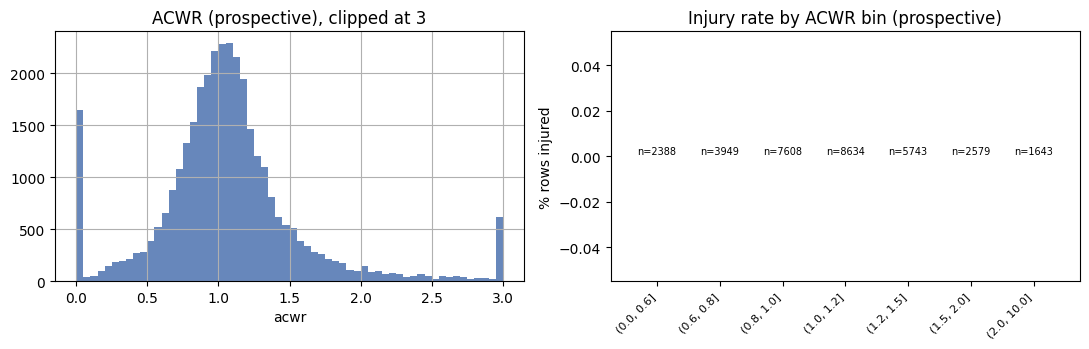

In [9]:
# Quick shape check on the headline feature: ACWR distribution + injury rate by bin.
# This is a look, not a result - real evaluation happens in 04 on proper splits.
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
X.acwr__pros.clip(0, 3).hist(bins=60, ax=ax[0], color='#4C72B0', alpha=.85)
ax[0].set_title('ACWR (prospective), clipped at 3'); ax[0].set_xlabel('acwr')

bins = pd.cut(X.acwr__pros, [0, .6, .8, 1.0, 1.2, 1.5, 2.0, 10])
rate = X.groupby(bins, observed=True).injury.agg(['mean', 'size'])
ax[1].bar(range(len(rate)), 100 * rate['mean'], color='#C44E52', alpha=.85)
ax[1].set_xticks(range(len(rate)))
ax[1].set_xticklabels([str(i) for i in rate.index], rotation=45, ha='right', fontsize=8)
ax[1].set_title('Injury rate by ACWR bin (prospective)'); ax[1].set_ylabel('% rows injured')
for i, (m, n) in enumerate(zip(rate['mean'], rate['size'])):
    ax[1].text(i, 100 * m, f'n={n}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
print(rate.rename(columns={'mean': 'injury_rate', 'size': 'n_rows'}).round(4))

In [10]:
X.to_csv(OUT / 'features_day.csv.gz', index=False)
daily.to_csv(OUT / 'daily_series.csv.gz', index=False)
print('wrote', OUT / 'features_day.csv.gz', X.shape)
print('wrote', OUT / 'daily_series.csv.gz', daily.shape)
print('(data/processed is gitignored - athlete-day tables could reconstruct an '
      'individual log, which the data README forbids committing)')

wrote ../data/processed/features_day.csv.gz (42766, 31)
wrote ../data/processed/daily_series.csv.gz (49162, 12)
(data/processed is gitignored - athlete-day tables could reconstruct an individual log, which the data README forbids committing)


## Summary

- Daily series reconstructed **exactly** from overlapping windows (max disagreement 0)
  and re-validated against source rows (`km_7d` matches every row's own slot sum).
- Caught in validation: negative `day` values are real pre-Date-0 training history,
  not zero padding (a first draft dropped them and the anchor check failed by 16.4 km
  on athlete 0). The anchor check exists precisely to catch this class of mistake.
- 16 features x 2 framings (same-day / prospective) written to
  `data/processed/features_day.csv.gz`; label and athlete/date keys attached.
- Coverage gates leave most rows usable; the NaN table above is the honest price of
  refusing to zero-fill unlogged gaps.

Logged to `docs/assumptions_limitations.md`:
- gap days are unlogged-not-rest -> coverage gating (thresholds 5/7, 10/14, 20/28)
- coupled ACWR default, EWMA variant noted as an alternative
- same-day vs prospective framing both produced; **choice of headline framing is an
  open decision for 03**

Next (03): class-weighted logistic baseline on the prospective features, then XGBoost;
same-day variant kept for benchmark comparison against the paper.